In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [11]:
df = pd.read_csv('../../data/used_car_price_dataset_extended.csv')
X = df.drop("price_usd", axis=1)
y = df["price_usd"]

In [12]:
df.shape

(10000, 12)

In [13]:
df.columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count',
       'price_usd', 'brand', 'transmission', 'color', 'service_history',
       'accidents_reported', 'insurance_valid'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


Categorical values - fuel type , brand , transmission , color , service history
Numerical Values - milege kmpl , make year , engine cc, owner count , accidents reported
Target - price usd

In [15]:
df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [16]:
df.isnull().sum()

make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
#describe our target variable  
df["price_usd"].describe()

count    10000.000000
mean      7179.754532
std       2795.270940
min       1000.000000
25%       5176.547500
50%       6961.260000
75%       8993.732500
max      17647.630000
Name: price_usd, dtype: float64

In [19]:
df["brand"].value_counts()

brand
Nissan        1089
Volkswagen    1033
BMW           1021
Tesla         1006
Honda         1003
Chevrolet      999
Hyundai        989
Toyota         956
Kia            955
Ford           949
Name: count, dtype: int64

From the above result , we can conclude that , our brand values are dsitributed balanced. The largest value for the Brand is Nissan = 1089 , lowest Ford = 949 , the difference is 140 , so its just 1.4 Percent of total database ,so we need not to change anything.

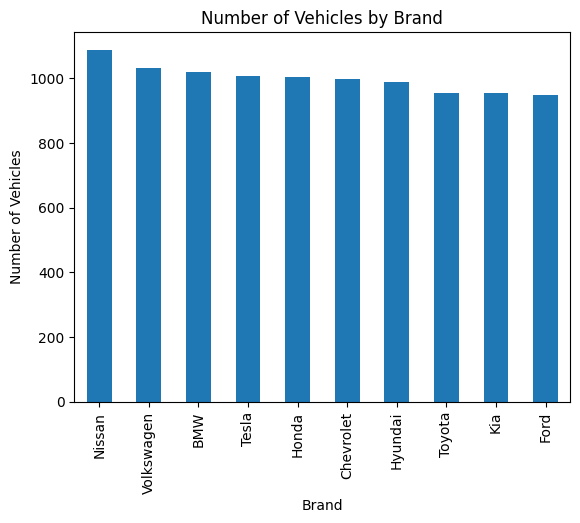

In [20]:
import matplotlib.pyplot as plt

df["brand"].value_counts().plot(kind="bar")

plt.title("Number of Vehicles by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Vehicles")

plt.show()

We just created Bar Graph For Our Understanding. We can clearly see how well it is distributed.There is nothing special about brand that makes it the first variable. We chose it because it's one of the categorical variables, and we need to learn EDA systematically.
Are some brands massively overrepresented?

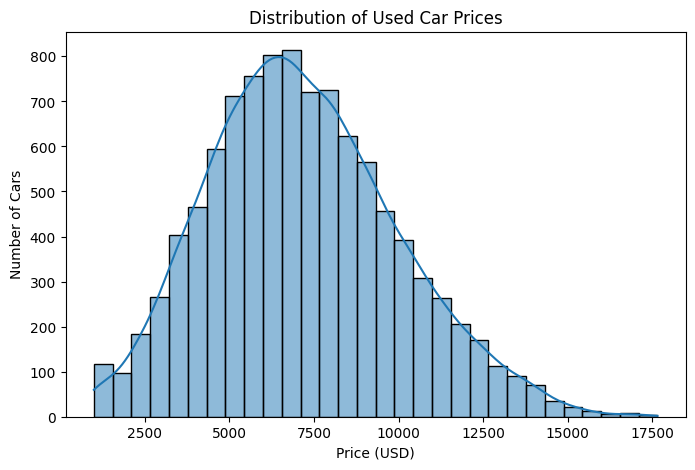

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df["price_usd"], bins=30, kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Cars")

plt.show()

In [22]:
#Now we will see the values distribution of other categorical features like fuel type, transmission, and body type.
df["fuel_type"].value_counts()

fuel_type
Petrol      4968
Diesel      4058
Electric     974
Name: count, dtype: int64

Petrol is the largest group.
Diesel is also very well represented.
Electric is considerably smaller, at about 9.7%

Even Though , there is no even distribution , i won't consider this as a serious concern , because , it is not our final prediction/target variable. If our final prediction is classification , like find it is pertrol / Disel / Electric , then we need to worry about it. Now , we are concentrating on numerical values , price_usd not classifcation.

We can record:

Petrol and diesel vehicles dominate the dataset, while electric vehicles represent approximately 9.7%. All three categories have sufficient observations, although electric vehicles are less represented.
But How ? 
Electric vehicles represent 9.74% of the dataset (974 observations). This is a smaller subgroup than Petrol and Diesel, but it is sufficiently represented for further exploratory analysis. Its effect on vehicle price should be investigated rather than assumed.

In [23]:
#Now transmission
df["transmission"].value_counts()

transmission
Manual       5985
Automatic    4015
Name: count, dtype: int64

Observation : Manual vehicles are more common

In [24]:
df["color"].value_counts()

color
Gray      1705
Black     1702
Red       1678
White     1651
Blue      1634
Silver    1630
Name: count, dtype: int64

The six vehicle colors are very evenly distributed, with each category representing approximately 16–17% of the dataset. No color is substantially over- or under-represented.

In [25]:
#service_history has missing value , so we should include dropna 
df["service_history"].value_counts(dropna=False)

service_history
Full       4987
Partial    2975
NaN        2038
Name: count, dtype: int64

If we delete , the rows that don't have service history , then we could lose 20 percent of our data ,we'd throw away 2,038 vehicles just because this one feature is missing, thats not recommended. But in EDA , we are not neccessarily make those decisions. EDA is only for understanding data.

In [26]:
df["insurance_valid"].value_counts()

insurance_valid
Yes    7934
No     2066
Name: count, dtype: int64

Again, because our target is continuous price_usd, we're not dealing with the kind of class-imbalance problem you'd worry about in a classification task.

Now , We are understanding the Numerical Values. Its continuous values , already we have description() , mean , max , min , median. Now , we are going into bigger picture.

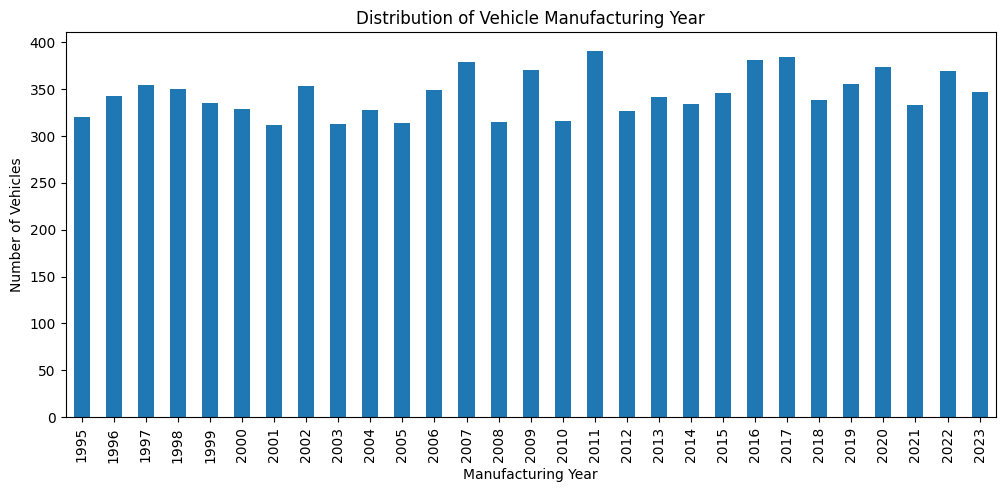

In [27]:
import matplotlib.pyplot as plt

# df["make_year"].plot(kind="hist", bins=20)
df["make_year"].value_counts().sort_index().plot(kind="bar", figsize=(12, 5))

plt.title("Distribution of Vehicle Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Vehicles")

plt.show()

I don't see any outliers , a car in 2050. 1995 - 2023 , fairly spreaded data. 
Question : Why we get uneven histogram before , as a group, but even when it is separate?
We asked Pandas/Matplotlib to divide those 29 years into only 20 bins.

So some bins contain one year, while others contain two years.

For example, imagine:

Bin 1 → 1995
Bin 2 → 1996–1997
Bin 3 → 1998
Bin 4 → 1999–2000
...

If 1996 has ~340 vehicles and 1997 has ~350:

1996–1997
340 + 350 = 690 vehicles

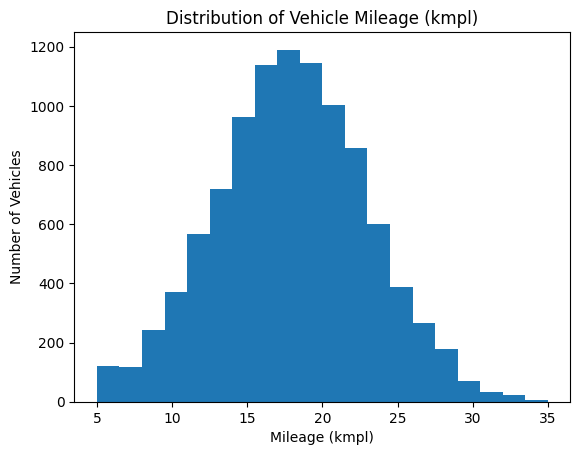

In [28]:
df["mileage_kmpl"].plot(kind="hist",bins=20)
plt.title("Distribution of Vehicle Mileage (kmpl)")
plt.xlabel("Mileage (kmpl)")
plt.ylabel("Number of Vehicles")
plt.show()

mileage_kmpl ranges from 5 to 35 km/l and is approximately bell-shaped and symmetric, with most observations concentrated around 15–20 km/l. No obvious extreme anomalies are visible from the histogram

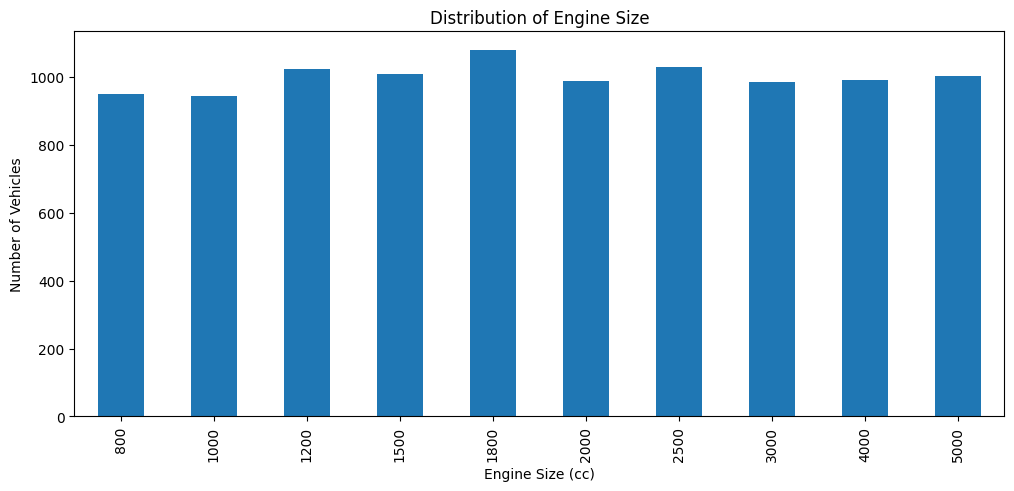

In [29]:
df["engine_cc"].value_counts().sort_index().plot(kind="bar", figsize=(12,5))

plt.title("Distribution of Engine Size")
plt.xlabel("Engine Size (cc)")
plt.ylabel("Number of Vehicles")

plt.show()

engine_cc is a discrete numerical variable in this dataset, containing 10 distinct engine-size values ranging from 800 cc to 5000 cc. The categories are relatively evenly represented.

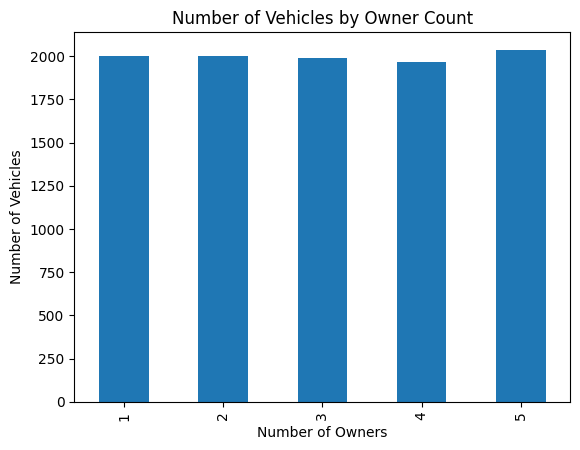

In [30]:
df["owner_count"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Vehicles by Owner Count")
plt.xlabel("Number of Owners")
plt.ylabel("Number of Vehicles")

plt.show()

owner_count contains five discrete values (1–5), with approximately 2,000 vehicles in each category. The distribution is highly balanced and shows no obvious unusual values.

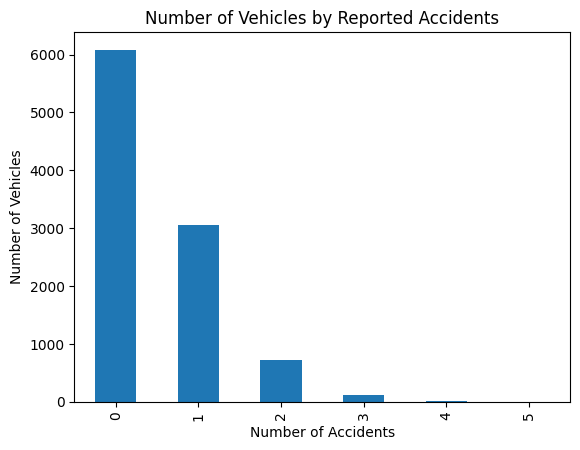

In [31]:
df["accidents_reported"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Vehicles by Reported Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Number of Vehicles")

plt.show()

Graph shows a strongly right-skewed distribution.
Most vehicles have zero reported accidents.
Then the number of vehicles drops rapidly as accident count increases.
Vehicles with no reported accidents are much more common than vehicles with multiple accidents.
accidents_reported ranges from 0 to 5 and is strongly right-skewed. Most vehicles have zero reported accidents, while observations with multiple accidents are increasingly rare. There are no obviously invalid values based on the observed range.
Does the number of reported accidents affect vehicle price?

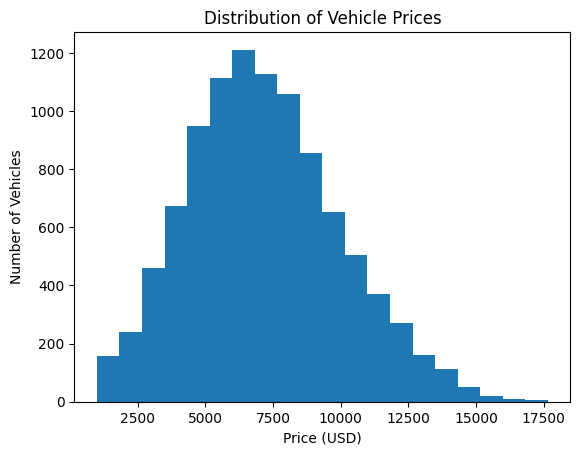

In [32]:
df["price_usd"].plot(kind="hist", bins=20)

plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Vehicles")

plt.show()

For Price Description , we have seen that , mean > median , so it is suggesting right-skewed , but not necessarily it is.
price_usd ranges from $1,000 to approximately $17,648. The distribution is concentrated around $5,000–$8,000 and shows moderate right skew, with relatively few higher-priced vehicles extending toward the maximum. The mean ($7,179.75) is slightly higher than the median ($6,961.26), consistent with this right skew.

We did analyse the numerical and categorical values using plot and pandas. 
Bivariate EDA, means , we are not yet analyse individually. Instead , we now analyse ,How does each feature relate to price_usd?
Like , Do vehicles with better mileage tend to have higher or lower prices?
We can identify it using , different plots , box plot for categorical values and scatter plot for numerical values.

make_year        → price
mileage_kmpl     → price
engine_cc        → price
owner_count      → price
accidents        → price

brand            → price
fuel_type        → price
transmission     → price
color            → price
service_history  → price
insurance_valid  → price

We can start With Numerical Values with Price.
Milage_kmpl

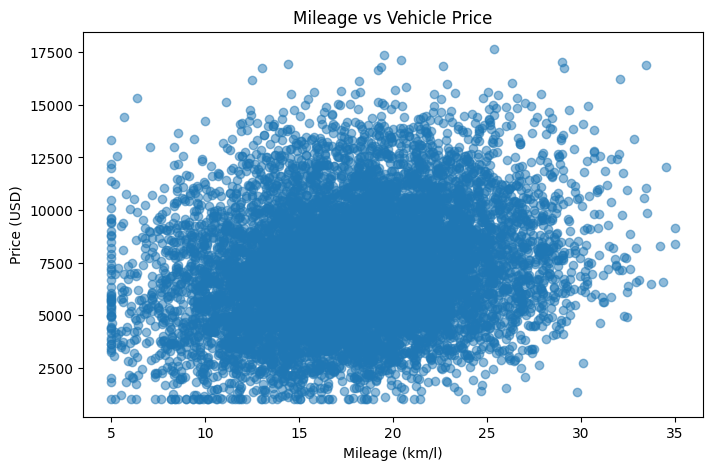

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df["mileage_kmpl"], df["price_usd"], alpha=0.5)

plt.title("Mileage vs Vehicle Price")
plt.xlabel("Mileage (km/l)")
plt.ylabel("Price (USD)")

plt.show()

Here, Each dot represents one vehicle. If the relationship is straight positive or negative , we can able to intercept something. But here , we can't able to decide anything, because it forms cloud like structure. So mileage alone doesn't appear to strongly determine price.

In [41]:
df["mileage_kmpl"].corr(df["price_usd"])

np.float64(0.2119705770050286)

mileage_kmpl has a weak positive linear relationship with price_usd.
In simpler terms:

Vehicles with higher fuel efficiency tend to have somewhat higher prices, but mileage alone is not a strong predictor of price.

|  `r` | Interpretation                       |
| ---: | ------------------------------------ |
|   +1 | Perfect positive linear relationship |
| +0.7 | Strong positive                      |
| +0.3 | Moderate positive                    |
|   ~0 | Little/no linear relationship        |
| −0.3 | Moderate negative                    |
| −0.7 | Strong negative                      |
|   −1 | Perfect negative                     |


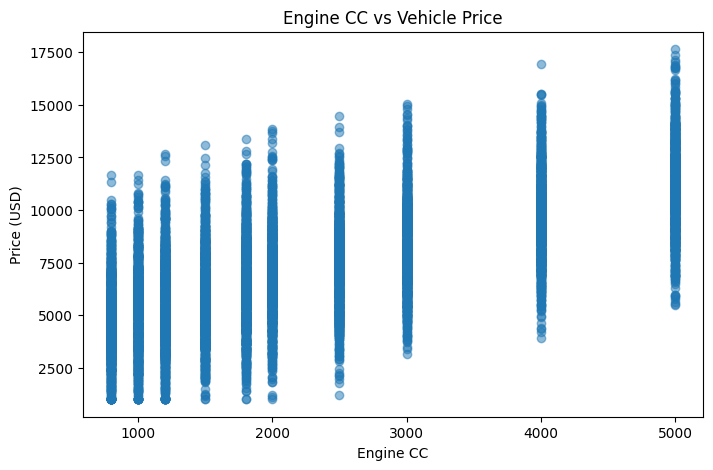

In [42]:
plt.figure(figsize=(8, 5))
plt.scatter(df["engine_cc"], df["price_usd"], alpha=0.5)
plt.title("Engine CC vs Vehicle Price")
plt.xlabel("Engine CC")
plt.ylabel("Price (USD)")
plt.show()

In [ ]:
df["engine_cc"].corr(df["price_usd"])

np.float64(0.6781612644756105)

engine_cc → price_usd

Visual: Clear positive upward relationship, although there is considerable variation within each engine-size group.

Correlation:

r=0.678
	​


Conclusion:

engine_cc has a moderately strong positive linear association with vehicle price. Larger-engine vehicles generally tend to have higher prices.

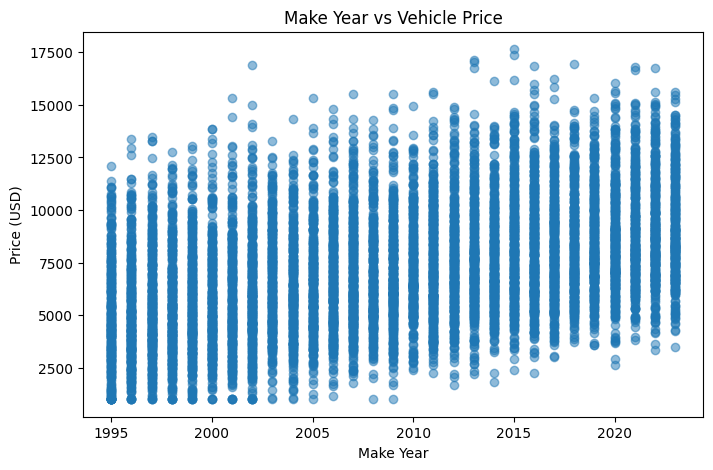

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(df["make_year"], df["price_usd"], alpha=0.5)

plt.title("Make Year vs Vehicle Price")
plt.xlabel("Make Year")
plt.ylabel("Price (USD)")

plt.show()

So visually, we have a positive relationship.
Newer vehicle ≠ automatically expensive vehicle.
The relationship isn't perfectly straight.
Other variables are clearly affecting price too.
Moderately strong positive.

In [44]:
df["make_year"].corr(df["price_usd"])

np.float64(0.43260258324002787)

make_year has a moderate positive linear association with price_usd (r=0.433). Newer vehicles tend to have higher prices, although substantial price variation remains within individual manufacturing years.

<Figure size 800x500 with 0 Axes>

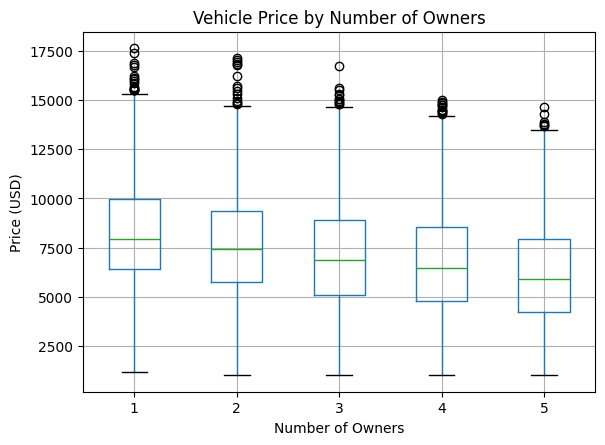

In [47]:
plt.figure(figsize=(8, 5))

df.boxplot(column="price_usd", by="owner_count")
# plt.scatter(df["owner_count"], df["price_usd"], alpha=0.5)
plt.title("Vehicle Price by Number of Owners")
plt.suptitle("")
plt.xlabel("Number of Owners")
plt.ylabel("Price (USD)")

plt.show()

We can clearly see that , more previous owners automatically mean that , lower the price.

In [ ]:
df["owner_count"].corr(df["price_usd"])
#Weak–moderate negative

np.float64(-0.2622655019472793)